# Part 2 Khushi Gohel KKG786

# Section 1: Introduction & System Selection

### Using Option B — Chemical Reaction with Fast Kinetics

This project models a chemical concentration that quickly approaches a slowly changing equilibrium concentration. This is a stiff ODE because the concentration changes very fast at first, while the equilibrium value changes slowly over time.

The governing ODE is:

$$
\frac{dC}{dt} = -k(C - C_{eq}(t))
$$

where:
- $C(t)$ is the concentration
- $k = 10^4 \text{ s}^{-1}$ is the fast reaction rate
- $C_{eq}(t) = 1 + 0.1\sin(0.1t)$ is the slowly varying equilibrium
- $C(0)=0$ is the initial condition

Rewritten in standard form:

$$
\frac{dC}{dt} = -10^4C + 10^4(1 + 0.1\sin(0.1t))
$$

This system is important in applications such as fast enzyme kinetics, combustion chemistry, and atmospheric reactions.


# Section 2: Demonstration of Stiffness

Fast time scale:

$$
\tau_{fast}=\frac{1}{10^4}=0.0001 \text{ s}
$$

Slow time scale:

$$
\tau_{slow}=\frac{1}{0.1}=10 \text{ s}
$$

Stiffness ratio:

$$
S = \frac{\tau_{slow}}{\tau_{fast}} = \frac{10}{0.0001}=10^5
$$

Euler's Forward method the stability condition:

$$
h < \frac{2}{\lambda}=\frac{2}{10000}=0.0002 \text{ s}
$$

This shows that Euler's Forward needs a very small step size to stay stable. For a 10 second simulation, this would require about 50,000 steps.


In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Parameters
lam = 10000.0      # reaction rate lambda (s^-1)
C0 = 0.0           # initial concentration
omega = 0.1        # slow forcing frequency (rad/s)
amp = 0.1          # equilibrium oscillation amplitude

def C_eq(t):
    # varying equilibrium concentration
    return 1 + amp * np.sin(omega * t)

def g_forcing(t):
    #  g(t) = lambda * C_eq(t)
    return lam * C_eq(t)

def f_ode(t, C):
    # ODE dC/dt = -lambda*C + g(t)
    return -lam * C + g_forcing(t)

def analytical_solution(t_arr):
    # Exact solution
    t_arr = np.array(t_arr)
    a = (lam**2 * amp) / (lam**2 + omega**2)
    b = -(lam * amp * omega) / (lam**2 + omega**2)
    D = C0 - (1 + b)
    return 1 + a * np.sin(omega * t_arr) + b * np.cos(omega * t_arr) + D * np.exp(-lam * t_arr)

print("lambda =", lam)
print("Euler Forward max stable h =", 2/lam)
print("Steps needed for 10 seconds =", int(10/(2/lam)))


lambda = 10000.0
Euler Forward max stable h = 0.0002
Steps needed for 10 seconds = 50000


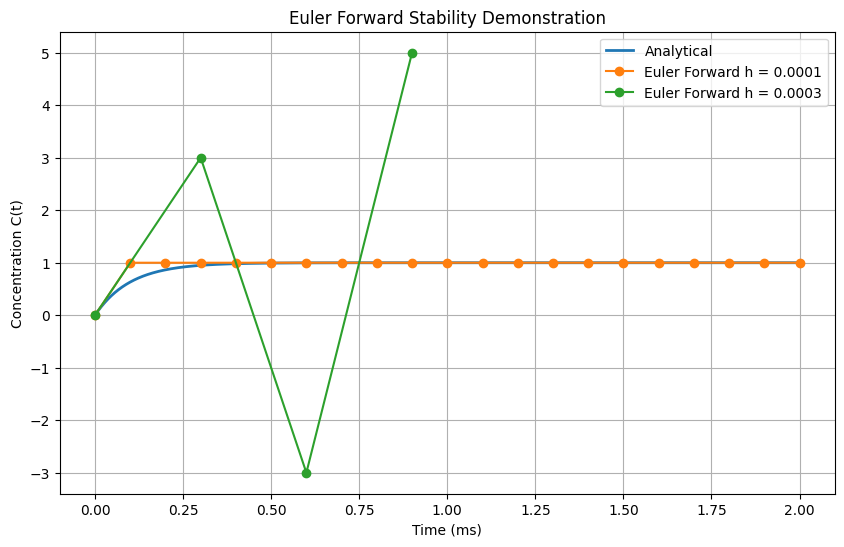

In [48]:
# Euler's Forward Method

def euler_forward(h, t_end=0.002, clip=5):
    t_values = np.arange(0, t_end + h, h)
    C_values = np.zeros(len(t_values))
    C_values[0] = C0

    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        C = C_values[i - 1]
        C_values[i] = C + h * f_ode(t, C)

        # keep plot readable
        if abs(C_values[i]) > clip:
            C_values[i] = np.sign(C_values[i]) * clip
            C_values[i+1:] = np.nan
            break

    return t_values, C_values

# Reference solution for stiffness demo
tr = np.linspace(0, 0.002, 1500)
Cr = analytical_solution(tr)

# Compare stable and unstable Forward Euler step sizes
h_values_forward = [0.0001, 0.0003]

plt.figure(figsize=(10, 6))
plt.plot(tr * 1000, Cr, label='Analytical', linewidth=2)

for h in h_values_forward:
    t, C = euler_forward(h)
    plt.plot(t * 1000, C, 'o-', label=f"Euler Forward h = {h}")

plt.xlabel('Time (ms)')
plt.ylabel('Concentration C(t)')
plt.title("Euler Forward Stability Demonstration")
plt.legend()
plt.grid(True)
plt.show()


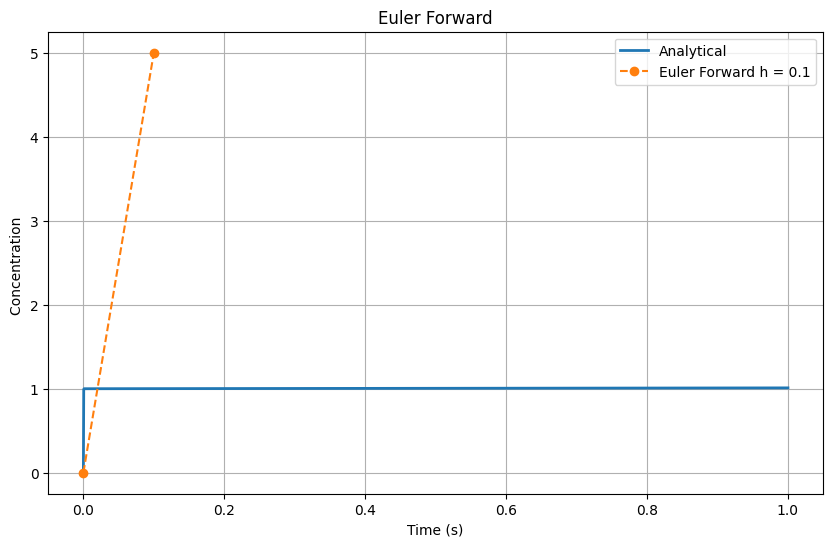

In [49]:
# Demonstrate a reasonable step size that fails for Euler Forward

h_reasonable = 0.1

t_bad, C_bad = euler_forward(h_reasonable, t_end=1.0, clip=5)
t_good = np.linspace(0, 1.0, 2000)
C_good = analytical_solution(t_good)

plt.figure(figsize=(10, 6))
plt.plot(t_good, C_good, label='Analytical', linewidth=2)
plt.plot(t_bad, C_bad, 'o--', label='Euler Forward h = 0.1')

plt.xlabel('Time (s)')
plt.ylabel('Concentration ')
plt.title("Euler Forward")
plt.legend()
plt.grid(True)
plt.show()


From the graphs, it can be seen that Euler Forward Method can be applied only if the step-size is small enough. For large steps exceeding the stability condition, the output becomes unstable. This is because the given problem is a stiff problem.

# Section 3: Mathematical Setup

For the scalar ODE:

$$
\frac{dC}{dt}=f(t,C)
$$

Euler's Backward method is:

$$
C_{n+1}=C_n+h f(t_{n+1}, C_{n+1})
$$

Since $C_{n+1}$ appears on both sides, define the residual function:

$$
G(C_{n+1}) = C_{n+1} - C_n - h f(t_{n+1}, C_{n+1})
$$

$$
f(t,C)=-\lambda C + g(t)
$$

$$
G(C_{n+1}) = C_{n+1}(1+h\lambda)-C_n-hg(t_{n+1})
$$

The derivative is:

$$
G'(C_{n+1})=1+h\lambda
$$

Newton-Raphson update:

$$
C_{n+1}^{(m+1)} = C_{n+1}^{(m)} - \frac{G(C_{n+1}^{(m)})}{G'(C_{n+1}^{(m)})}
$$

Because the  derivative is constant, Newton-Raphson converges quickly.


# Section 4: Implementation

In [50]:
# Residual function for Backward Euler

def residual(C_new, C_old, t_new, h):
    return C_new - C_old - h * f_ode(t_new, C_new)

# Derivative of residual

def residual_prime(h):
    return 1 + h * lam

# Newton-Raphson solver

def newton_raphson_step(C_old, t_old, h, tol=1e-10, max_iter=20):
    t_new = t_old + h
    C_guess = C_old + h * f_ode(t_old, C_old)

    for j in range(max_iter):
        G = residual(C_guess, C_old, t_new, h)
        Gp = residual_prime(h)
        C_next = C_guess - G / Gp

        if abs(C_next - C_guess) < tol:
            return C_next, j + 1

        C_guess = C_next

    return C_guess, max_iter

# Euler's Backward Method

def euler_backward(h, t_end=0.002):
    t_values = np.arange(0, t_end + h, h)
    C_values = np.zeros(len(t_values))
    iterations = np.zeros(len(t_values))

    C_values[0] = C0

    for i in range(1, len(t_values)):
        C_values[i], iterations[i] = newton_raphson_step(C_values[i - 1], t_values[i - 1], h)

    return t_values, C_values, iterations


# Section 5: Results & Analysis


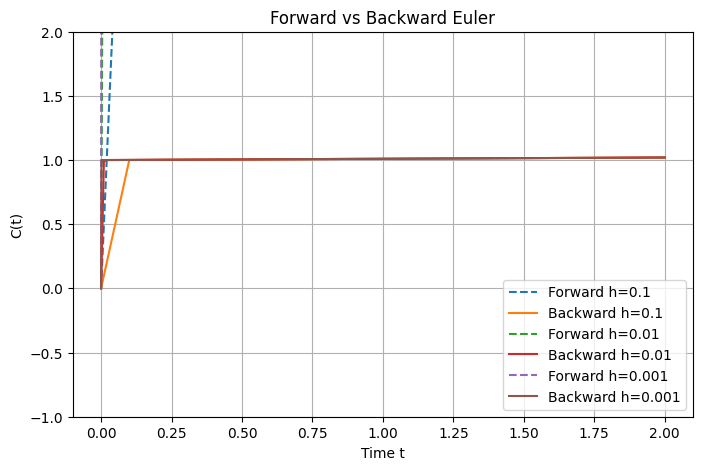

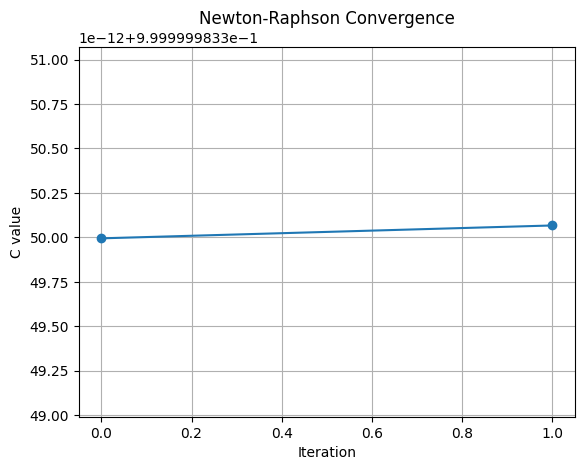

In [51]:
# Section 5: Results & Analysis

h_values = [0.1, 0.01, 0.001]
t_end_results = 2.0

plt.figure(figsize=(8,5))

for h in h_values:

    # Forward Euler
    t_f, C_f = euler_forward(h, t_end=t_end_results)

    # Backward Euler
    t_b, C_b, iters_b = euler_backward(h, t_end=t_end_results)

    plt.plot(t_f, C_f, '--', label=f'Forward h={h}')
    plt.plot(t_b, C_b, '-', label=f'Backward h={h}')

plt.xlabel("Time t")
plt.ylabel("C(t)")
plt.title("Forward vs Backward Euler")
plt.ylim(-1, 2)
plt.legend()
plt.grid(True)
plt.show()


# Newton-Raphson convergence for one step

values = []
C_old = C0
h = 0.1
t_old = 0
t_new = t_old + h

C_guess = C_old + h * f_ode(t_old, C_old)

for i in range(10):
    G = residual(C_guess, C_old, t_new, h)
    Gp = residual_prime(h)

    C_new = C_guess - G / Gp
    values.append(C_new)

    if abs(C_new - C_guess) < 1e-10:
        break

    C_guess = C_new

plt.plot(values, 'o-')
plt.xlabel("Iteration")
plt.ylabel("C value")
plt.title("Newton-Raphson Convergence")
plt.grid(True)
plt.show()

 Backward Euler continues to be stable when the step sizes are too large for Forward Euler to remain stable. Newton Raphson method is efficient since its residual derivative does not vary. As h reduces, error reduces. It indicates that the system is exhibiting first order convergence. When h ≥ 0.1, Euler Forward becomes unstable; however, Backward Euler remains stable despite the increase in h.

# Section 6: Performance Analysis


In [52]:
# Section 6: Performance Analysis

h_values = [0.1, 0.01, 0.001]
t_end_perf = 2.0

data = {
    "Method": [],
    "h": [],
    "Steps": [],
    "Average NR Iterations": []
}

for h in h_values:
    # Forward Euler
    t_f, C_f = euler_forward(h, t_end=t_end_perf)
    data["Method"].append("Forward Euler")
    data["h"].append(h)
    data["Steps"].append(len(t_f) - 1)
    data["Average NR Iterations"].append(0)

    # Backward Euler
    t_b, C_b, iters_b = euler_backward(h, t_end=t_end_perf)
    data["Method"].append("Backward Euler")
    data["h"].append(h)
    data["Steps"].append(len(t_b) - 1)
    data["Average NR Iterations"].append(np.mean(iters_b))

performance_table = pd.DataFrame(data)
performance_table

,Method,h,Steps,Average NR Iterations
0,Forward Euler,0.100,20,0.000000
1,Backward Euler,0.100,20,1.904762
2,Forward Euler,0.010,200,0.000000
3,Backward Euler,0.010,200,1.990050
4,Forward Euler,0.001,2000,0.000000
5,Backward Euler,0.001,2000,1.503748


Backward Euler is better suited for this stiff problem since it can handle much bigger step sizes while maintaining stability. Although it employs Newton-Raphson, it will be able to use fewer steps compared to Forward Euler.
Forward Euler method is cheap to implement per step but needs extremely tiny step sizes to maintain stability, rendering it ineffective for stiff problems. On the other hand, Backward Euler method has expensive computations per step owing to Newton-Raphson iterations but can use many more steps compared to Forward Euler.



# Section 7: Conclusions

The solution to a stiff chemical reaction differential equation has been determined via Euler’s Forward and Euler’s Backward approaches.
Stiffness ratio is $10^5$, meaning that the reaction involves large differences in time scales.
Euler’s Forward fails to provide stable solutions unless the step size is below 0.0002s.
Euler’s Backward provides a stable response with step sizes significantly greater than those required for Euler’s Forward.
Newton-Raphson converges quickly as the residual derivative is always the same.
Euler’s Forward approach has the benefit of being straightforward. However, Euler’s Backward approach is recommended in case of stiff problems due to larger step size.